# From Speech to Print

## Setup

Agregamos la carpeta padre al Path para poder importar el módulo `cowaver`:

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import cowaver

Definimos una función que nos será util para escuchar audios.

In [2]:
import io
import torch
import torchaudio
import ipywidgets as widgets
from cowaver.utils import AUDIO_SAMPLE_RATE

def audio_widget(waveform: torch.Tensor):
    if waveform.dim() == 1:
        waveform = waveform.unsqueeze(0)

    buffer = io.BytesIO()
    torchaudio.save(buffer, waveform.cpu(), AUDIO_SAMPLE_RATE, format="wav")
    buffer.seek(0)

    return widgets.Audio(
        value=buffer.read(),
        format="wav",
        autoplay=False,
        loop=False,
        controls=True,
    )

Configuramos las constantes de este notebook:

In [3]:
from pathlib import Path
from cowaver.utils import encontrar_dispositivo

# Idioma, puede ser "french" o "spanish"
LANGUAGE = "french"

# Tamaño del dataset disponible
DATASET_SIZE = 480

# URL al checkpoint de CORnet-Z
CORNET_CKPT_URL = "https://s3.amazonaws.com/cornet-models/cornet_z-5c427c9c.pth"

# Rutas a los datos
workspace_path = Path("../") / LANGUAGE
compressed_phones_path = workspace_path / f"kalulu-phones-{DATASET_SIZE}.tar.xz"
compressed_spoken_path = workspace_path / f"kalulu-spoken-{DATASET_SIZE}.tar.xz"

print(f"Buscando {compressed_phones_path}", end="... ")
print("OK" if compressed_phones_path.exists() else "ERROR")

print(f"Buscando {compressed_spoken_path}", end="... ")
print("OK" if compressed_spoken_path.exists() else "ERROR")

# Carpeta donde se descomprimirán los datos
data_path = workspace_path / "data"

# Carpeta donde se guardan los checkpoints
checkpoints_path = workspace_path / "checkpoints" / str(DATASET_SIZE)

Buscando ../french/kalulu-phones-480.tar.xz... OK
Buscando ../french/kalulu-spoken-480.tar.xz... OK


## Conjuntos de datos: TinyPairedMel

El conjunto de datos se divide en _Training Set_ y _Generalization Set_. El primero contiene un número de palabras con las que se entrenará la conciencia fonológica, mientras que el segundo contendrá palabras no vistas (pero sí por el Speech Autoencoder), que servirá para poner a prueba la capacidad de generalización de la conciencia fonológica.

Ejecutá la celda siguiente para descomprimir los datos y armar los conjuntos de _Training_ y _Generalization_.

In [4]:
from cowaver.utils import descomprimir_archivo, listar_clases, separar_clases
from cowaver.datamodules import TinyPairedMel

phones_path = descomprimir_archivo(compressed_phones_path, data_path)
spoken_path = descomprimir_archivo(compressed_spoken_path, data_path)

palabras = listar_clases(phones_path / "train")

print("Total de palabras:", len(palabras))

palabras_a_entrenar, palabras_a_generalizar = separar_clases(palabras, fraction=0.2)
print("Palabras a entrenar:", len(palabras_a_entrenar))
print(f"Palabras a generalizar ({len(palabras_a_generalizar)}):", palabras_a_generalizar)

full_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras)
training_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_entrenar)
generalization_data = TinyPairedMel(phones_path, spoken_path, mel_bins=80, classes=palabras_a_generalizar)

Descomprimiendo ../french/kalulu-phones-480.tar.xz en ../french/data/kalulu-phones-480... YA EXISTE
Descomprimiendo ../french/kalulu-spoken-480.tar.xz en ../french/data/kalulu-spoken-480... YA EXISTE
Total de palabras: 480
Palabras a entrenar: 384
Palabras a generalizar (96): ['abeille', 'aigle', 'aile', 'après', 'arc', 'assise', 'auto', 'avez', 'avion', 'base', 'bien', 'bête', 'cage', 'chasse', 'chaud', 'cirque', 'colle', 'colère', 'cousin', 'dent', 'devant', 'domino', 'doux', 'désert', 'filet', 'fine', 'foyer', 'gagnant', 'gagné', 'gare', 'grotte', 'guide', 'jambe', 'jardin', 'jouant', 'jour', 'karaté', 'leçon', 'loup', 'lundi', 'malade', 'marine', 'masque', 'monstre', 'moule', 'mousse', 'météo', 'neveu', 'niche', 'niveau', 'noté', 'noyer', 'nul', 'onze', 'ours', 'passé', 'pendant', 'perdu', 'petit', 'phrase', 'piano', 'pin', 'piqué', 'pirate', 'porte', 'porter', 'pâte', 'quart', 'que', 'radio', 'reine', 'renard', 'reste', 'riant', 'rouge', 'savoir', 'ses', 'soleil', 'station', 'suje

La siguiente celda permite explorar el conjunto de datos:

In [5]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 4), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        plt.show()

    display(widgets.VBox([out, widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform)])]))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Speech Autoencoder

### Definición

In [6]:
from cowaver.modules.reading import SpeechAutoEncoder

speech_autoencoder = SpeechAutoEncoder()
print(speech_autoencoder)

SpeechAutoEncoder(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=94464, out_features=256, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(32, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(32, 41, 72))
    (lin): Linear(in_features=256, out_features=94464, bias=True)
  )
)


### Entrenamiento

In [8]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
speech_autoencoder = SpeechAutoEncoder()
speech_autoencoder, train_history = entrenar_red(net=speech_autoencoder, data=full_data, programme=programme)
# guardar_checkpoint(speech_autoencoder, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red speech_autoencoder_hd256_sl49_mb80
Época 1/30 | train_loss=2.6503 | val_loss=0.7363
Época 2/30 | train_loss=0.8914 | val_loss=0.5174
Época 3/30 | train_loss=0.4873 | val_loss=0.3337
Época 4/30 | train_loss=0.3738 | val_loss=0.3510
Época 5/30 | train_loss=0.3286 | val_loss=0.2585
Época 6/30 | train_loss=0.2452 | val_loss=0.2091
Época 7/30 | train_loss=0.1853 | val_loss=0.1584
Época 8/30 | train_loss=0.1685 | val_loss=0.2083
Época 9/30 | train_loss=0.1702 | val_loss=0.1357
Época 10/30 | train_loss=0.1377 | val_loss=0.1418
Época 11/30 | train_loss=0.1155 | val_loss=0.1192
Época 12/30 | train_loss=0.1010 | val_loss=0.1098
Época 13/30 | train_loss=0.1006 | val_loss=0.1028
Época 14/30 | train_loss=0.0904 | val_loss=0.1030
Época 15/30 | train_loss=0.0820 | val_loss=0.1025
Época 16/30 | train_loss=0.0751 | val_loss=0.0893
Época 17/30 | train_loss=0.0684 | val_loss=0.0828
Época 18/30 | train_loss=0.0621 | val_loss=0.0797
Época 19/30 | t

### Evaluación

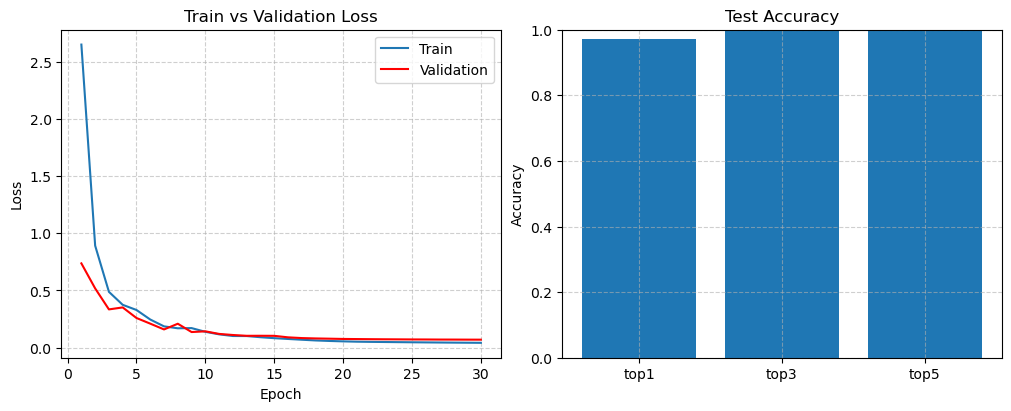

In [10]:
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

speech_autoencoder = SpeechAutoEncoder()
train_history = cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
test_results = evaluar_red(speech_autoencoder, full_data)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(test_results, ax=axes[1])
plt.show()

### Exploración

In [11]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import SpeechAutoEncoder
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel

speech_autoencoder = SpeechAutoEncoder()
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
speech_autoencoder.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, _, spoken_mel), target = exploration_set[idx]
    spoken_waveform = extraer_waveform(spoken_mel)

    with torch.no_grad():
        reconstructed_mel = speech_autoencoder(spoken_mel.unsqueeze(1).transpose(2, 3))
    reconstructed_mel = reconstructed_mel.squeeze(1).transpose(1, 2)
    reconstructed_waveform = extraer_waveform(reconstructed_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(2, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(spoken_waveform, ax=axes[0][0])
        graficar_mel(spoken_mel, ax=axes[0][1])
        graficar_waveform(reconstructed_waveform, ax=axes[1][0])
        graficar_mel(reconstructed_mel, ax=axes[1][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(spoken_waveform), audio_widget(reconstructed_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Red de conciencia fonológica

### Definición

In [12]:
from cowaver.modules.reading import PhonologicalAwareness

phonological_awareness = PhonologicalAwareness()
print(phonological_awareness)

PhonologicalAwareness(
  (encoder): ConvEncoder(
    (bias): BiasLayer()
    (conv_1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1))
    (conv_2): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (lin): Linear(in_features=94464, out_features=256, bias=True)
  )
  (decoder): ConvDecoder(
    (bias): BiasLayer()
    (deconv_2): ConvTranspose2d(32, 1, kernel_size=(5, 5), stride=(1, 1))
    (deconv_1): ConvTranspose2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
    (unflatten): Unflatten(dim=-1, unflattened_size=(32, 41, 72))
    (lin): Linear(in_features=256, out_features=94464, bias=True)
  )
)


### Entrenamiento

In [13]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.models import TrainProgramme
from cowaver.utils import sembrar_semilla, entrenar_red
from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=30,
    epsilon_zero=1e-3,
    theta=20,
    epsilon_theta=1e-4,
    patience=3
)

# Uncomment to train
#
sembrar_semilla(40)
phonological_awareness = PhonologicalAwareness()

speech_autoencoder = SpeechAutoEncoder()
cargar_checkpoint(speech_autoencoder, folder=checkpoints_path, silent=True)
phonological_awareness.load_state_dict(speech_autoencoder.state_dict())

phonological_awareness, train_history = entrenar_red(net=phonological_awareness, data=training_data, programme=programme)
guardar_checkpoint(phonological_awareness, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 40... OK
Buscando dispositivo... MPS
Red phonological_awareness_hd256_sl49_mb80
Época 1/30 | train_loss=2.1481 | val_loss=1.5290
Época 2/30 | train_loss=1.1755 | val_loss=1.1319
Época 3/30 | train_loss=0.7473 | val_loss=0.9570
Época 4/30 | train_loss=0.5242 | val_loss=0.8876
Época 5/30 | train_loss=0.4017 | val_loss=0.7952
Época 6/30 | train_loss=0.3136 | val_loss=0.7503
Época 7/30 | train_loss=0.2542 | val_loss=0.7739
Época 8/30 | train_loss=0.2141 | val_loss=0.7398
Época 9/30 | train_loss=0.1870 | val_loss=0.7380
Época 10/30 | train_loss=0.1605 | val_loss=0.7052
Época 11/30 | train_loss=0.1360 | val_loss=0.7004
Época 12/30 | train_loss=0.1222 | val_loss=0.7041
Época 13/30 | train_loss=0.1076 | val_loss=0.7077
Época 14/30 | train_loss=0.0961 | val_loss=0.6965
Época 15/30 | train_loss=0.0865 | val_loss=0.7052
Época 16/30 | train_loss=0.0770 | val_loss=0.6965
Época 17/30 | train_loss=0.0698 | val_loss=0.7074
El entrenamiento finalizó de forma prematura.
Guardando check

### Evaluación

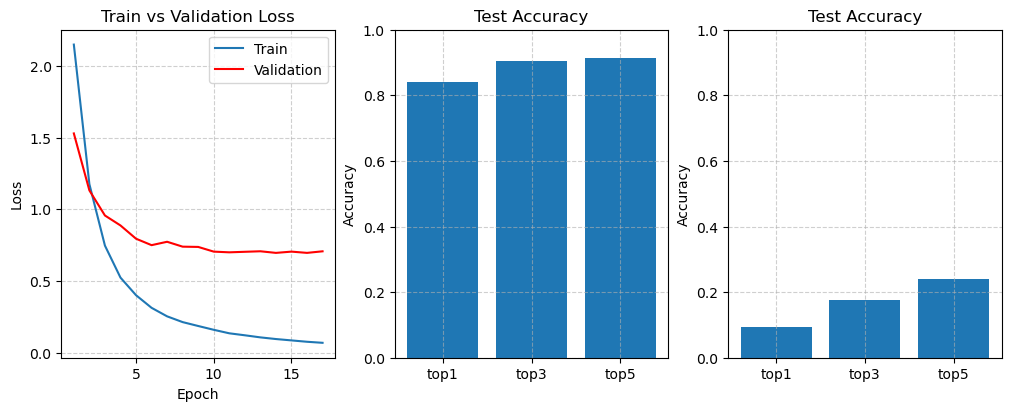

In [14]:
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import evaluar_red
from cowaver.checkpoints import cargar_checkpoint
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_awareness = PhonologicalAwareness()
train_history = cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_awareness, training_data)
generalization_test_results = evaluar_red(phonological_awareness, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 4), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [15]:
import matplotlib.pyplot as plt
from cowaver.modules.reading import PhonologicalAwareness
from cowaver.utils import extraer_waveform
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_awareness = PhonologicalAwareness()
cargar_checkpoint(phonological_awareness, folder=checkpoints_path, silent=True)
phonological_awareness.eval()
exploration_set = full_data.test_set

@widgets.interact(idx=(0, len(exploration_set) - 1))
def explore_test_set(idx=0):
    (image, phonetized_mel, spoken_mel), target = exploration_set[idx]
    phonetized_waveform = extraer_waveform(phonetized_mel)
    spoken_waveform = extraer_waveform(spoken_mel)

    phonetized_mel = phonetized_mel.unsqueeze(1).transpose(2, 3)
    with torch.no_grad():
        h = phonological_awareness.encoder(phonetized_mel)
        mel_hat = phonological_awareness.decoder(h)
    predicted_mel = mel_hat.squeeze(1).transpose(1, 2)
    predicted_waveform = extraer_waveform(predicted_mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(3, 2, figsize=(10, 6), layout="constrained")
        fig.suptitle(exploration_set.classes[target])
        graficar_waveform(phonetized_waveform, ax=axes[0][0])
        graficar_mel(phonetized_mel, ax=axes[0][1])
        graficar_waveform(spoken_waveform, ax=axes[1][0])
        graficar_mel(spoken_mel, ax=axes[1][1])
        graficar_embedding(h, ax=axes[2][0], vmin=h.min(), vmax=h.max())
        graficar_mel(predicted_mel, ax=axes[2][1])
        plt.show()
        
    display(widgets.VBox([
        out, 
        widgets.HBox([audio_widget(phonetized_waveform), audio_widget(spoken_waveform), audio_widget(predicted_waveform)])]
    ))

interactive(children=(IntSlider(value=0, description='idx', max=479), Output()), _dom_classes=('widget-interac…

## Ruta fonológica de la lectura

### Definición

In [7]:
from cowaver.modules.reading import PhonologicalRoute

phonological_route = PhonologicalRoute()
print(phonological_route)

PhonologicalRoute(
  (cornet): DataParallel(
    (module): Sequential(
      (V1): CORblock_Z(
        (conv): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V2): CORblock_Z(
        (conv): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (V4): CORblock_Z(
        (conv): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (nonlin): ReLU(inplace=True)
        (pool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (output): Identity()
      )
      (IT): CORblock_Z(
        (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      

### Entrenamiento

In [22]:
from cowaver.models import TrainProgramme
from cowaver.utils import entrenar_red
# from cowaver.checkpoints import guardar_checkpoint

programme = TrainProgramme(
    theta_max=60,
    epsilon_zero=1e-3,
    theta=45,
    epsilon_theta=1e-4,
    patience=7
)

# Uncomment to train
#
phonological_route = PhonologicalRoute()

checkpoint = torch.utils.model_zoo.load_url(CORNET_CKPT_URL, map_location=torch.device("cpu"))
phonological_route.cornet.load_state_dict(checkpoint["state_dict"], strict=False)

cargar_checkpoint(phonological_route.phonological_awareness, folder=checkpoints_path, silent=True)
 
all_h = []
phonological_route.phonological_awareness.eval()
with torch.no_grad():
    for batch in training_data.train_loader():
        (_, phonetized_mel, _), labels = batch
        phonetized_mel = phonetized_mel.transpose(2, 3)
        h = phonological_route.phonological_awareness.encoder(phonetized_mel)
        all_h.append(h)
all_h = torch.cat(all_h, dim=0)
h_mean = all_h.mean(dim=0)
h_std = all_h.std(dim=0)
phonological_route.set_h_stats(h_mean, h_std)

phonological_route, train_history = entrenar_red(net=phonological_route, data=training_data, programme=programme)
guardar_checkpoint(phonological_route, train_history=train_history, programme=programme, folder=checkpoints_path)

Sembrando semilla 42... OK
Buscando dispositivo... MPS
Red phonological_route_hd256_sl49_mb80
Época 1/60 | train_loss=0.9243 | val_loss=0.6594
Época 2/60 | train_loss=0.7174 | val_loss=0.5617
Época 3/60 | train_loss=0.5917 | val_loss=0.4959
Época 4/60 | train_loss=0.5185 | val_loss=0.4638
Época 5/60 | train_loss=0.4704 | val_loss=0.4452
Época 6/60 | train_loss=0.4350 | val_loss=0.4259
Época 7/60 | train_loss=0.4130 | val_loss=0.4171
Época 8/60 | train_loss=0.3947 | val_loss=0.4106
Época 9/60 | train_loss=0.3810 | val_loss=0.4035
Época 10/60 | train_loss=0.3705 | val_loss=0.3983
Época 11/60 | train_loss=0.3628 | val_loss=0.3960
Época 12/60 | train_loss=0.3563 | val_loss=0.3926
Época 13/60 | train_loss=0.3503 | val_loss=0.3906
Época 14/60 | train_loss=0.3465 | val_loss=0.3908
Época 15/60 | train_loss=0.3413 | val_loss=0.3870
Época 16/60 | train_loss=0.3384 | val_loss=0.3836
Época 17/60 | train_loss=0.3342 | val_loss=0.3833
Época 18/60 | train_loss=0.3319 | val_loss=0.3832
Época 19/60 | t

### Evaluación

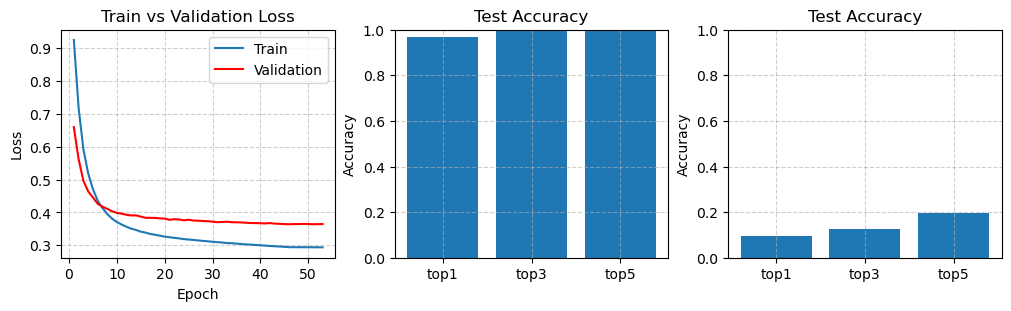

In [10]:
from cowaver.modules.reading import PhonologicalRoute
from cowaver.checkpoints import cargar_checkpoint
from cowaver.utils import evaluar_red
from cowaver.plots import graficar_train_history, graficar_test_results

phonological_route = PhonologicalRoute()
train_history = cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
training_test_results = evaluar_red(phonological_route, training_data)
generalization_test_results = evaluar_red(phonological_route, generalization_data)

fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
graficar_train_history(train_history, ax=axes[0])
graficar_test_results(training_test_results, ax=axes[1])
graficar_test_results(generalization_test_results, ax=axes[2])
plt.show()

### Exploración

In [11]:
import matplotlib.pyplot as plt
from cowaver.utils import extraer_waveform, make_image
from cowaver.plots import graficar_waveform, graficar_mel, graficar_embedding

phonological_route = PhonologicalRoute()
cargar_checkpoint(phonological_route, folder=checkpoints_path, silent=True)
phonological_route.eval()

@widgets.interact(word="buzo")
def explore_phonological_route(word: str):
    image = make_image(word)
    with torch.no_grad():
        mel, h = phonological_route(image)
    mel = mel.squeeze(1).transpose(1, 2)
    waveform = extraer_waveform(mel)

    out = widgets.Output()
    with out:
        fig, axes = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")
        fig.suptitle(word)
        graficar_waveform(waveform, ax=axes[0])
        graficar_mel(mel, ax=axes[1])
        graficar_embedding(h, ax=axes[2], vmin=h.min(), vmax=h.max())
        plt.show()
        
    display(widgets.VBox([out, audio_widget(waveform)]))

interactive(children=(Text(value='buzo', description='word'), Output()), _dom_classes=('widget-interact',))